# Generate bound curves for all methods on dSprites

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pickle
import yaml

import torch
from torch.utils.data import DataLoader
from torch.autograd import Variable
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

from geometry.datasets import custom_dsprites
from geometry.datasets.generic_dataset_loader import DatasetName, load_dataset
from geometry.computations_grid.data_analysis.data_analysis import (
    compute_measures_multiclass,
    plot_pairs_multiclass,
    plot_3d_pca_projections_multiclass,
    clip_results_multiclass,
    MeasureAggregates
)
from representation_learning.beta_vae.solver import Solver
from representation_learning.beta_vae.dataset import CustomTensorDataset
from experiment_scripts.model_configs import BetaVAEConfig
from representation_learning.beta_vae.utils import cuda
from geometry.datasets.generic_dataset_loader import load_dataset_fixed_test_split

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## Load the measures for all datasets

In [4]:
normalize_for_volume = True
number_of_dims = 4
output_dir = Path(f"~/experiments/manifold_microscope/manifold_fitting/measures_all_datasets/dsprites_measures_vol_norm_{normalize_for_volume}").expanduser() 

output_path = output_dir / f"dsprites_{number_of_dims}.pkl"
with open(output_path, "rb") as f:
    measures_dsprites = clip_results_multiclass(pickle.load(f))

## Load the results

In [5]:
def parse_path(path):
    dataset_name, _, perc_data, dim, _, iteration = path.name.split("__")
    
    checkpoints = list(path.glob("checkpoints/*rec_loss*"))

    if not (path / "checkpoints" / "last.pth").exists():
        return None
        
    checkpoint_infos = [
        (
            int(ckpt.stem.split("_")[1]), 
            float(ckpt.stem.split("_")[4]),
            float(ckpt.stem.split("_")[7]),
            float(ckpt.stem.split("_")[10])
        ) 
        for ckpt in checkpoints
    ]

    model_stop_iteration, rec_loss, haus_dist, avg_dist = max(checkpoint_infos, key=lambda x: x[0])

    return dict(
        dataset_name=dataset_name,
        perc_data=perc_data,
        dim=int(dim),
        iteration=iteration,
        model_stop_iteration=model_stop_iteration,
        train_rec_loss=rec_loss, 
        train_haus_dist=haus_dist, 
        train_avg_dist=avg_dist,
        model_path=path / "checkpoints" / "last.pth",
        dataset_path=path.parent / "datasets" / f"{dataset_name}__{dim}.npz",
        config_path=path / "config.yml"
    )

In [6]:
paths = list(Path("~/experiments/manifold_microscope/manifold_fitting/training_absolute_ratio_dl_models_fixed_test_set_dsprites_FINAL").expanduser().glob("*"))

In [7]:
path_infos = [parse_path(p) for p in paths if p.name != "datasets" if parse_path(p) is not None]

In [8]:
def load_the_test_data(config: BetaVAEConfig):
    datasets_dir = config.exported_datasets_dir
    dataset_name = config.dataset
    number_of_dims = config.number_of_dims
    training_ratio = config.training_ratio
    noise_sigma = 0.0
    
    data_train, data_test, _, _ = load_dataset_fixed_test_split(
        datasets_dir=datasets_dir,
        dataset_name=dataset_name,
        number_of_dims=number_of_dims,
        ratio_per_dim=False,
        training_ratio=training_ratio,
        noise_sigma=noise_sigma,
        weight_subsampling_by_manifold_volume=True
    )
    
    print(f"Number test: {len(data_test)}")

    data_test = (data_test - data_test.min()) / (data_test.max() - data_test.min())
    data_test = torch.from_numpy(data_test).unsqueeze(1).float()

    test_kwargs = {'data_tensor': data_test}

    test_data = CustomTensorDataset(**test_kwargs)
    test_loader = DataLoader(
        test_data,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=False
    )

    return test_loader, len(data_train), len(data_test)


@torch.no_grad()
def compute_distance_metrics(solver, data_loader):
    all_distances = []
    for x in tqdm(data_loader, total=len(data_loader)):
        x = Variable(cuda(x, solver.use_cuda))
        x_recon, _, _ = solver.net(x)
        x_recon = F.sigmoid(x_recon)
        
        distances = torch.linalg.norm((x_recon - x).flatten(start_dim=1), axis=-1)
        all_distances.append(distances.detach().cpu().numpy())

    all_distances = np.concatenate(all_distances, axis=0)

    return all_distances.max(), all_distances.mean()


def compute_distances(row):
    model_path = row["model_path"]
    config_path = row["config_path"]

    if not model_path.exists():
        return dict(
        test_hausdorff_distance=None,
        test_average_distance=None,
        n_train=None,
        n_test=None
    )

    with open(str(config_path), 'r') as f:
        config_dict = yaml.load(f, Loader=yaml.UnsafeLoader)

    config = BetaVAEConfig(**config_dict["model_config"])
    
    solver = Solver(config, load_data=False)
    solver.load_checkpoint("last.pth")

    data_loader, n_train, n_test = load_the_test_data(config)

    hausdorff_distance, average_distance = compute_distance_metrics(solver, data_loader)

    return dict(
        test_hausdorff_distance=hausdorff_distance,
        test_average_distance=average_distance,
        n_train=n_train,
        n_test=n_test
    )

In [ ]:
all_infos = [
    info | compute_distances(info)
    for info in tqdm(path_infos)
    if info["dim"] == 4
]

df = pd.DataFrame(all_infos)

In [ ]:
df.head(3)

## Generate the curves

In [11]:
results_df = []

for path in Path("~/experiments/manifold_microscope/manifold_fitting/training_absolute_ratio_dl_models_fixed_test_set_mmls_FINAL").expanduser().glob("**/*.pkl"):
    dataset, method, data_perc, dims, noise, n_iter = path.parent.name.split("__")
    
    with open(path, "rb") as f:
        results = pickle.load(f)

    results_df.append(dict(
        dataset=dataset,
        method=method,
        data_perc=float(data_perc), 
        dims=int(dims), 
        noise=float(noise), 
        n_iter=int(n_iter),
        number_of_train_points=results["number_of_train_points"],
        number_of_test_points=results["number_of_test_points"],
        hausdorff_distance=results["hausdorff_distance"],
        avg_distance=results["pointwise_distances"].mean()
    ))

results_df = pd.DataFrame(results_df)
results_df = results_df[(results_df["dims"] == 4) & (results_df["dataset"] == "custom_dsprites_balanced")]

In [12]:
results_df.shape

(39, 10)

In [13]:
results_df.head()

,dataset,method,data_perc,dims,noise,n_iter,number_of_train_points,number_of_test_points,hausdorff_distance,avg_distance
4,custom_dsprites_balanced,MMLS,0.70,4,0.0,1,137275,500,2.815711,0.694557
11,custom_dsprites_balanced,MMLS,0.80,4,0.0,1,156886,500,2.626897,0.663727
12,custom_dsprites_balanced,MMLS,0.30,4,0.0,1,58832,500,3.746525,1.137041
17,custom_dsprites_balanced,MMLS,0.05,4,0.0,0,9805,500,5.004093,2.463012
18,custom_dsprites_balanced,MMLS,0.90,4,0.0,1,176497,500,2.600549,0.658447


In [ ]:
dim = 4
dataset = "custom_dsprites_balanced"

df_dsprites_1 = (
    df
    [(df["dim"] == dim) & (df["dataset_name"] == dataset) & (~df["test_hausdorff_distance"].isna())]
    .sort_values("perc_data")
    .reset_index(drop=True)
)
df_dsprites_1.head(3)

In [15]:
df_dsprites_1 = (
    df_dsprites_1
    .assign(
        data_perc=lambda df: df["perc_data"].astype(np.float64),
        hausdorff_distance=lambda df: df["test_hausdorff_distance"]
    )
    .merge(results_df[["data_perc", "number_of_train_points"]].drop_duplicates(), on="data_perc")
)

In [ ]:
df_dsprites_1

## Polish and export bounds

In [17]:
%matplotlib inline

In [18]:
def robust_lower_bound(f_values, g, x, q=0.01):
    lower_bound = g(x)
    return np.quantile(f_values / lower_bound, q=q)

def robust_upper_bound(f_values, g, x, q=0.99):
    upper_bound = g(x)
    return np.quantile(f_values / upper_bound, q=q)

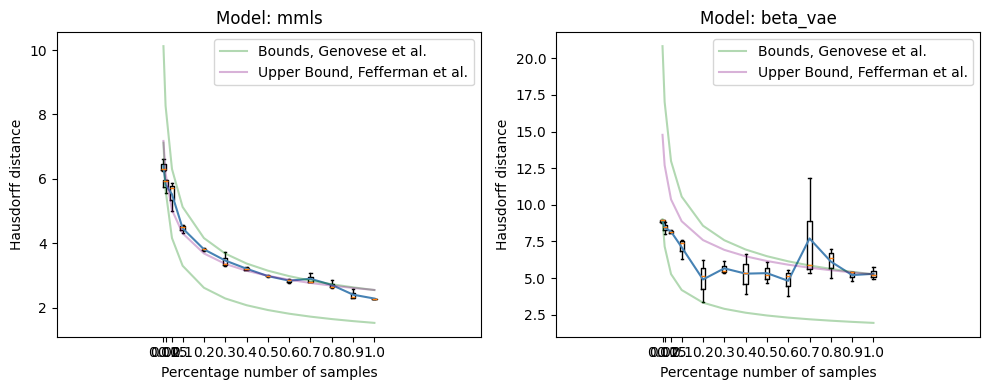

In [20]:
def g_lower_genovese(x): 
    return (1/x)**(2/(2 + d))
def g_upper_genovese(x): 
    return (np.log(x)/x)**(2/(2 + d))

def g_upper_fefferman(x): 
    return (np.log(x) / x)**(1/d)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

curves_to_export = {}

for i, model_name in enumerate(["mmls", "beta_vae"]):
    d = 4
    tau = np.min(list(measures_dsprites.measure_aggregates.normalized_min_reaches.values()))
    
    match model_name:
        case "mmls":
            dataset_results = (
                results_df
                .groupby("number_of_train_points")
                .agg(list)
            )
            
        case "beta_vae":
            dataset_results = (
                df_dsprites_1
                .groupby("number_of_train_points")
                .agg(list)
            )
    
    haus_all = dataset_results["hausdorff_distance"]
    
    f_values_haus = np.array(haus_all.map(np.mean))
    x = np.array(dataset_results.index)

    x_perc = np.array(dataset_results["data_perc"].str[0])

    x_log = np.log(x).reshape(-1, 1)
    y_log = np.log(f_values_haus)
    
    # linear regression
    reg = LinearRegression().fit(x_log, y_log)
    alpha_fit = -reg.coef_[0]
    C_fit = np.exp(reg.intercept_)
    f_vals_fitted = C_fit * x**(-alpha_fit)
    
    C1 = robust_lower_bound(f_vals_fitted, g_lower_genovese, x)
    C2 = robust_upper_bound(f_vals_fitted, g_upper_genovese, x)
    C = robust_upper_bound(f_vals_fitted, g_upper_fefferman, x)
    
    yl = C1 * g_lower_genovese(x)
    yu = C2 * g_upper_genovese(x)
    yu_f = C * g_upper_fefferman(x)

    curves_to_export[model_name] = {
        "x": x, 
        "empirical": f_values_haus, 
        "empirical_all_repetitions": haus_all, 
        "lower_genovese": yl, 
        "upper_genovese": yu, 
        "upper_fefferman": yu_f
    }
    
    ax = axes[i]
    # ax.set_title(f"C1: {C1:.2f}, C2: {C2:.2f}, C: {C:.2f}")
    ax.set_title(f"Model: {model_name}")
    ax.boxplot(haus_all, positions=x_perc, widths=0.02)
    ax.plot(x_perc, f_values_haus, color="steelblue")
    # ax[1].plot(x, f_vals_fitted, color="steelblue")
    ax.plot(x_perc, yl, color="green", alpha=0.3, label="Bounds, Genovese et al.")
    ax.plot(x_perc, yu, color="green", alpha=0.3)
    ax.plot(x_perc, yu_f, color="purple", alpha=0.3, label="Upper Bound, Fefferman et al.")
    # ax[1].set_ylim((0, 1.05*f_values_haus.max()))
    ax.set_xlabel("Percentage number of samples")
    ax.set_ylabel("Hausdorff distance")
    ax.legend()

np.savez("all_models_bounds.npz", **curves_to_export)

plt.tight_layout()
plt.savefig("all_models_bounds.png", dpi=200)
plt.show()